# RAG 

**Retrieval-Augmented Generation (RAG)** is an AI framework that improves Large Language Model (LLM) outputs by retrieving relevant, 
up-to-date data from external,trusted sources—like corporate databases or the internet—before generating a response.


Core Idea: Instead of relying only on the LLM’s static training data (which may be outdated or hallucinated), RAG pulls real-time or domain-specific knowledge at inference time.


**RAG has 3 core components:**



**Retriever**  → finds relevant information

**Augmenter**  → builds the prompt with that information

**Generator**  → produces the final answer

### Preprocessing of RAG

This is the offline phase that prepares your knowledge base so retrieval can be fast and accurate later.


#### 1. Document Loading (Ingestion)

**Purpose**: Read unstructured or semi-structured data from various sources.

**Common Sources:**

* Text files (.txt, .md)
* PDFs (reports, manuals)
* Web pages (HTML)
* Databases (SQL, NoSQL)
* APIs (Notion, Confluence, SharePoint)
* Code repositories (GitHub)

**Tools:**


* PDF's - Unstructured, PyPDF2, pdfplumber 
* For HTML - BeautifulSoup,Selenium
* LangChain / LlamaIndex document loaders
* Custom scripts for internal DBs


**Challenges:**

* PDFs with scanned images → need OCR (Tesseract, Google Vision),
* Tables, headers, footers → may need special parsing,
* Encoding issues (UTF-8 vs. Latin-1).


#### 2. Document Cleaning & Normalization

**Purpose**: Remove noise and standardize text.


**Common Operations:**

* Remove boilerplate (headers, footers, disclaimers)
* Fix encoding errors
* Replace Unicode characters (e.g., smart quotes → straight quotes)
* Expand contractions (“don’t” → “do not”) — optional
* Lowercase? → Usually NO (preserves entity names, acronyms)


#### 3. Text Chunking (Splitting)

**Purpose:** Break long documents into smaller, semantically meaningful pieces.

beacuse of LLMs have context limits (e.g., 8K–128K tokens), and retrieval works best on focused passages.


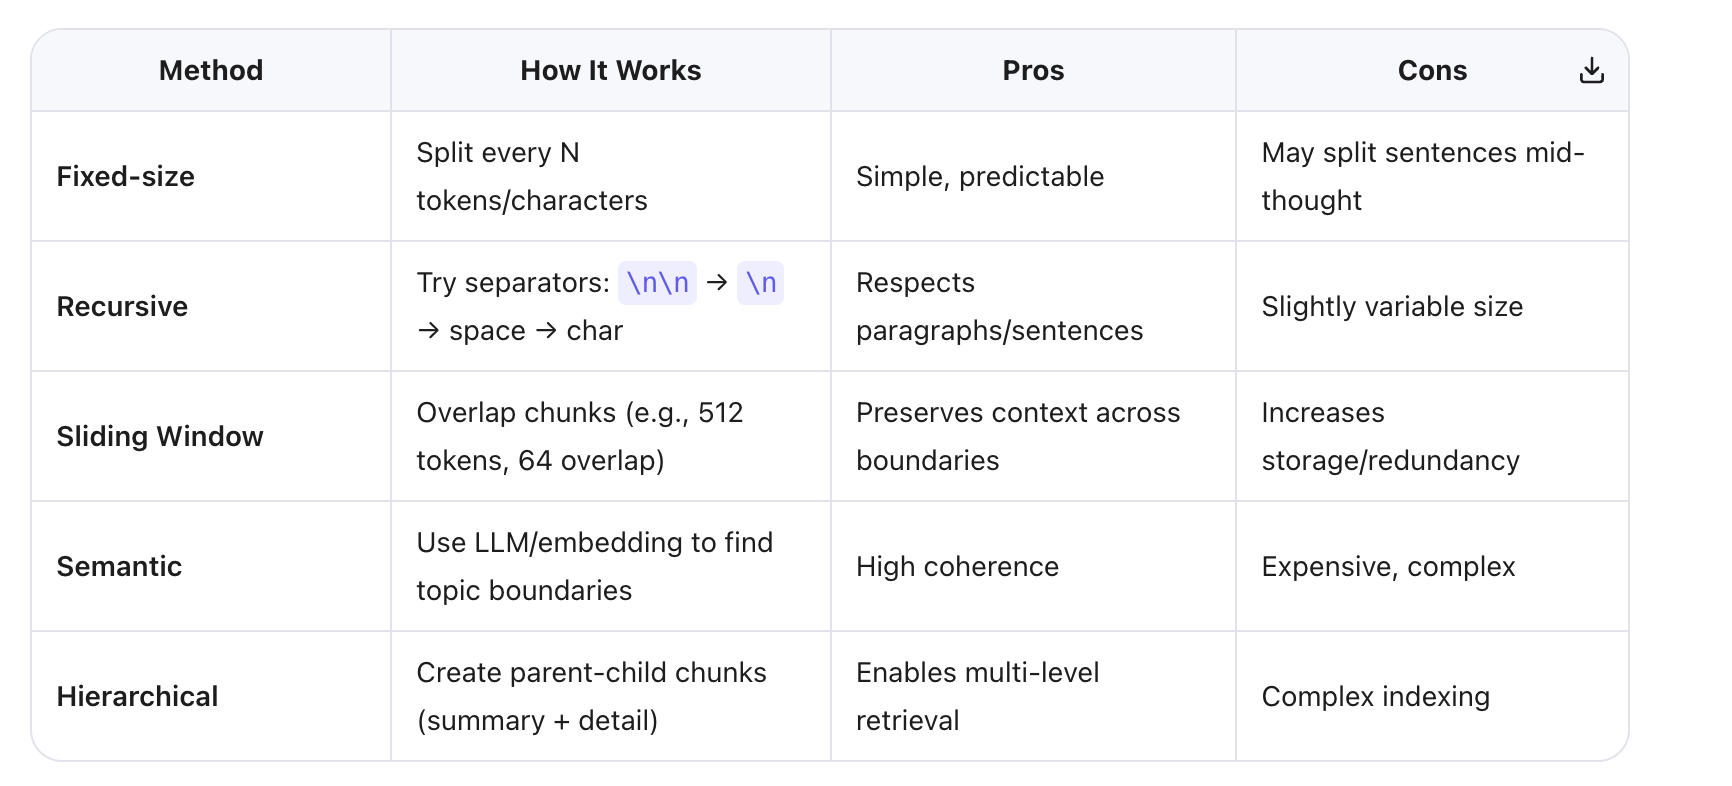


**Typical Chunk Sizes:**

LLM context: 512–1024 tokens (for embedding + prompt)
Embedding models: Often optimized for 256–512 tokens
Best Practice: Use recursive splitting with overlap (e.g., 500 tokens + 50 overlap).




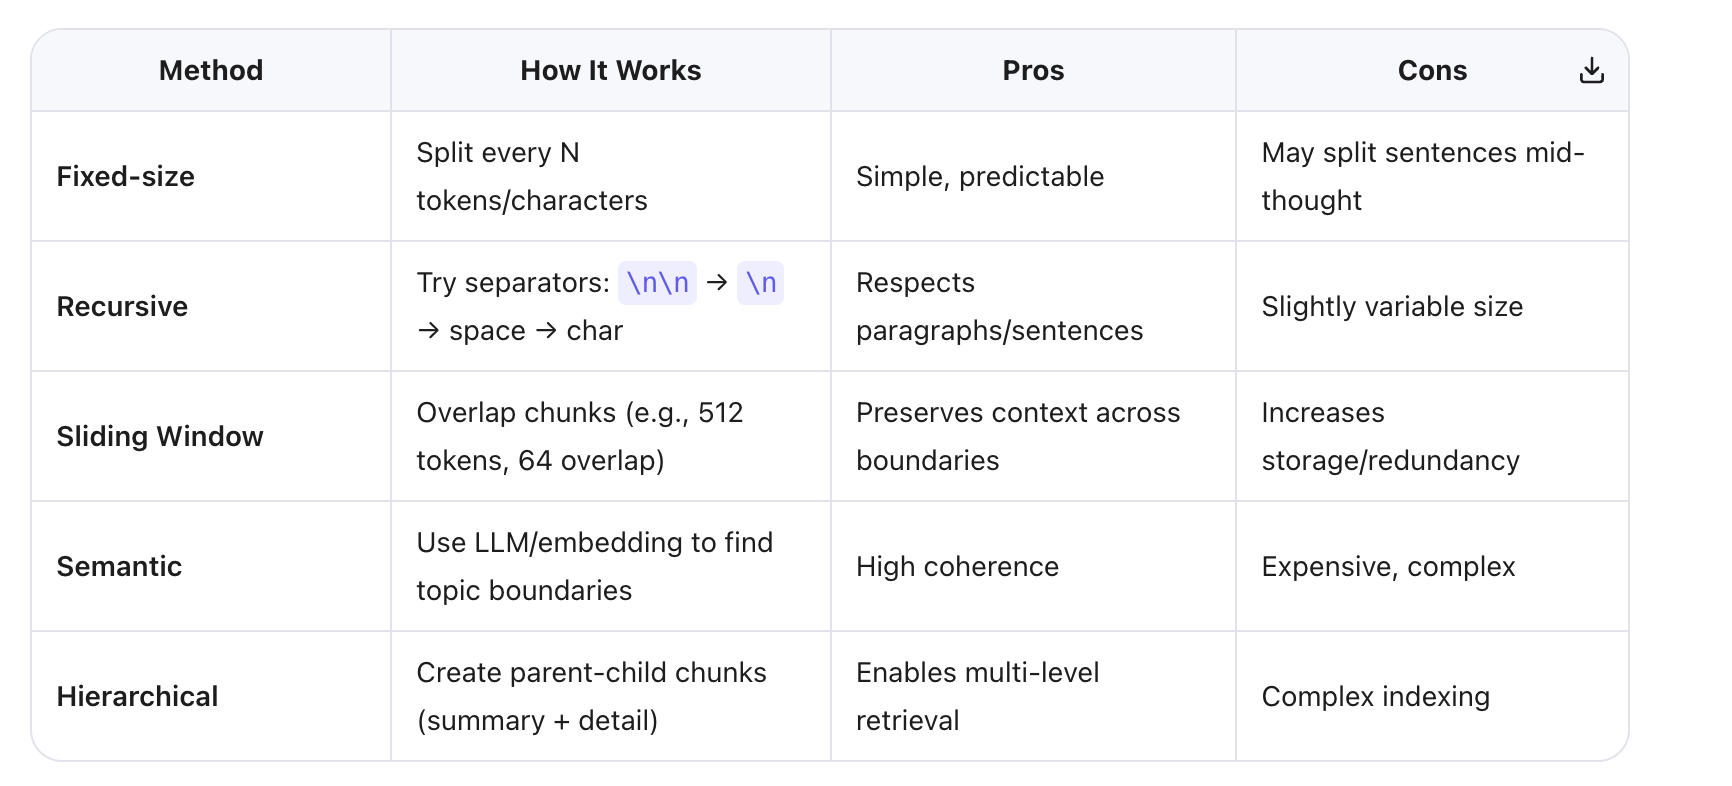

### RETRIEVER (Search Engine Part)

***Takes a user query and Finds the most relevant Information/chunks from your database***

User Query → Convert to embedding → Search vector DB → Return top-k chunks



#### Main job of the retriever

**The retriever has 3 responsibilities:**

1. Represent the query in a searchable form.

2. Search the document store.

3. Return the best chunks, ideally ranked by relevance.


### Types of retrievers

There are three major families.


**1. Sparse retriever** : This is keyword-based retrieval.

Examples:

BM25
TF-IDF

How it works:

Matches exact or near-exact words from the query against documents.
Strong for specific terms, IDs, legal clauses, product names, codes.

Example:
Query:
“refund policy section 4.2”

Sparse retrieval is strong because “section 4.2” may not embed well semantically, but keyword matching catches it.

**Strengths:**

* Good for exact phrases
* Good for codes, names, numbers
* Fast


**Weaknesses:**

* Misses semantic similarity
* If wording changes, it may fail


**2. Dense retriever** : This is embedding-based retrieval.

Examples:

SentenceTransformers + FAISS
BGE embeddings + Chroma/Qdrant

How it works:

Convert chunks and query into vectors.
Search by similarity in vector space.

Example:
Query:
“What is the maximum amount employees can claim for travel?”

Retriever can find:
“Employees are eligible for reimbursement up to $500 per trip.”

Even though words differ, meaning is close.

**Strengths:**

* Strong semantic matching
* Good for natural questions
* Works very well for document QA


**Weaknesses:**


* Can miss exact tokens or IDs
* Sensitive to chunk quality and embedding quality


**3. Hybrid retriever** : This combines sparse + dense retrieval.

How it works:

* Run both keyword and vector search
* Merge or rerank results

This is often the best production approach.

**Strengths:**

Captures exact terms and semantic meaning
More robust

**Weaknesses:**

1.More engineering complexity
2.Slightly slower



**Tools used**

Sentence-transformers → create embeddings.

FAISS / Chroma / Qdrant → store & search vectors.



### AUGMENTER (Prompt Builder)

***It Combines: Retrieved chunks (context) + User question***

Builds a structured prompt for the LLM

#### Example Prompt
You are a helpful assistant.
Answer ONLY from the context.

CONTEXT:
Employees can claim up to $500 per trip.

QUESTION:
What is the reimbursement limit?

ANSWER:
You implement this yourself (or via LangChain)




Why it matters
Poor prompt = hallucinations
Good prompt = grounded, accurate answers

### GENERATOR (LLM)

***IT Takes the prompt and Generates a natural language answer***

**Models**:


* flan-t5
* mistral-7b
* llama3
* gpt-4





# Supporting Components 



###  Document Loader
Loads PDFs, DOCX, etc.
Tools: pdfplumber, python-docx



### Chunking System
Splits documents into smaller parts
Example: 800 tokens + overlap

### Embedding Model
Converts text → vectors
Example: all-MiniLM-L6-v2


### 7. Vector Database
Stores embeddings
Example: FAISS, Chroma, Qdrant

### 8. Retriever Interface
Converts DB into searchable API
retriever = vectordb.as_retriever()


### 9. Evaluation Layer
Checks:
accuracy
hallucination
retrieval quality

# comprehensive breakdown of RAG types


### 1. By Architecture Generation (Research Timeline)


1. Naive / Vanilla RAG
2. RAG-Token (Lewis et al. 2020)
3. RAG-Sequence (Lewis et al. 2020)
4. Self-RAG
5. CRAG (Corrective RAG)
6. FLARE


### 2. By Retrieval Strategy

1. Single-Step RAG (Vanilla)
2. Multi-Query RAG
3. Step-Back RAG
4. Recursive / Iterative RAG
5. HyDE (Hypothetical Document Embeddings

### 3. By Reasoning Pattern

1. Zero-Shot RAG
2. Few-Shot RAG
3. Chain-of-Thought (CoT) + RAG


### 4. By Indexing Strategy

1. Vector-Only RAG
2. Hybrid RAG
3. Graph RAG
4. Hirarchical RAG


### 5. Generation Control

1. Rerank-Then-Generate
2. Citation-Aware RAG
3. Query-Focused Summarization




## When to Use Which?
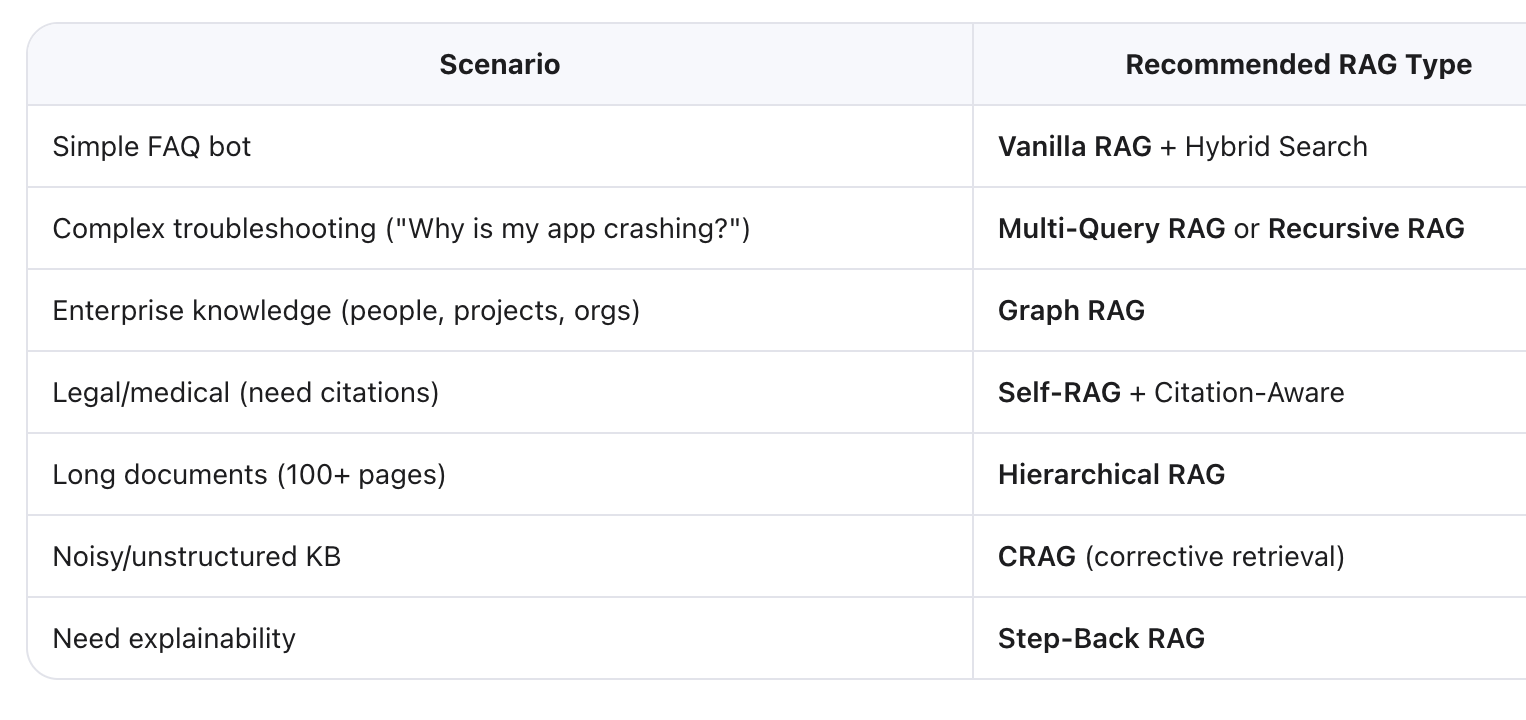

